In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/11157563_ejection_results.txt',on_bad_lines="skip")

In [3]:
df.columns=['mass','result','tmax']


In [4]:
df

,mass,result,tmax
0,0.001689,1,100.000000
1,0.001689,1,100.000000
2,0.001689,1,100.000000
3,0.001689,1,100.000000
4,0.001689,1,100.000000
...,...,...,...
599994,0.009495,1,200000.000000
599995,0.009495,1,189478.947368
599996,0.009495,1,200000.000000
599997,0.009495,1,200000.000000


In [5]:
prop_df=df.groupby(['mass', 'tmax']).size().reset_index(name='count')

In [6]:
prop_df

,mass,tmax,count
0,0.000300,100.000000,6000
1,0.000300,10621.052632,6000
2,0.000300,21142.105263,6000
3,0.000300,31663.157895,6000
4,0.000300,42184.210526,6000
...,...,...,...
95,0.009495,157915.789474,6000
96,0.009495,168436.842105,6000
97,0.009495,178957.894737,6000
98,0.009495,189478.947368,6000


In [7]:
ejected_df=df[df.result == 0]

In [8]:
grouped = (
    df.groupby(["mass", "tmax"])
      .agg(
          total_particles=("result", "size"),
          ejected_particles=("result", lambda x: (x == 0).sum())
      )
      .reset_index()
)

grouped["ejection_fraction"] = (
    grouped["ejected_particles"] / grouped["total_particles"]
)

In [9]:
grouped

,mass,tmax,total_particles,ejected_particles,ejection_fraction
0,0.000300,100.000000,6000,0,0.000000
1,0.000300,10621.052632,6000,0,0.000000
2,0.000300,21142.105263,6000,0,0.000000
3,0.000300,31663.157895,6000,0,0.000000
4,0.000300,42184.210526,6000,0,0.000000
...,...,...,...,...,...
95,0.009495,157915.789474,6000,3661,0.610167
96,0.009495,168436.842105,6000,3661,0.610167
97,0.009495,178957.894737,6000,3661,0.610167
98,0.009495,189478.947368,6000,3663,0.610500


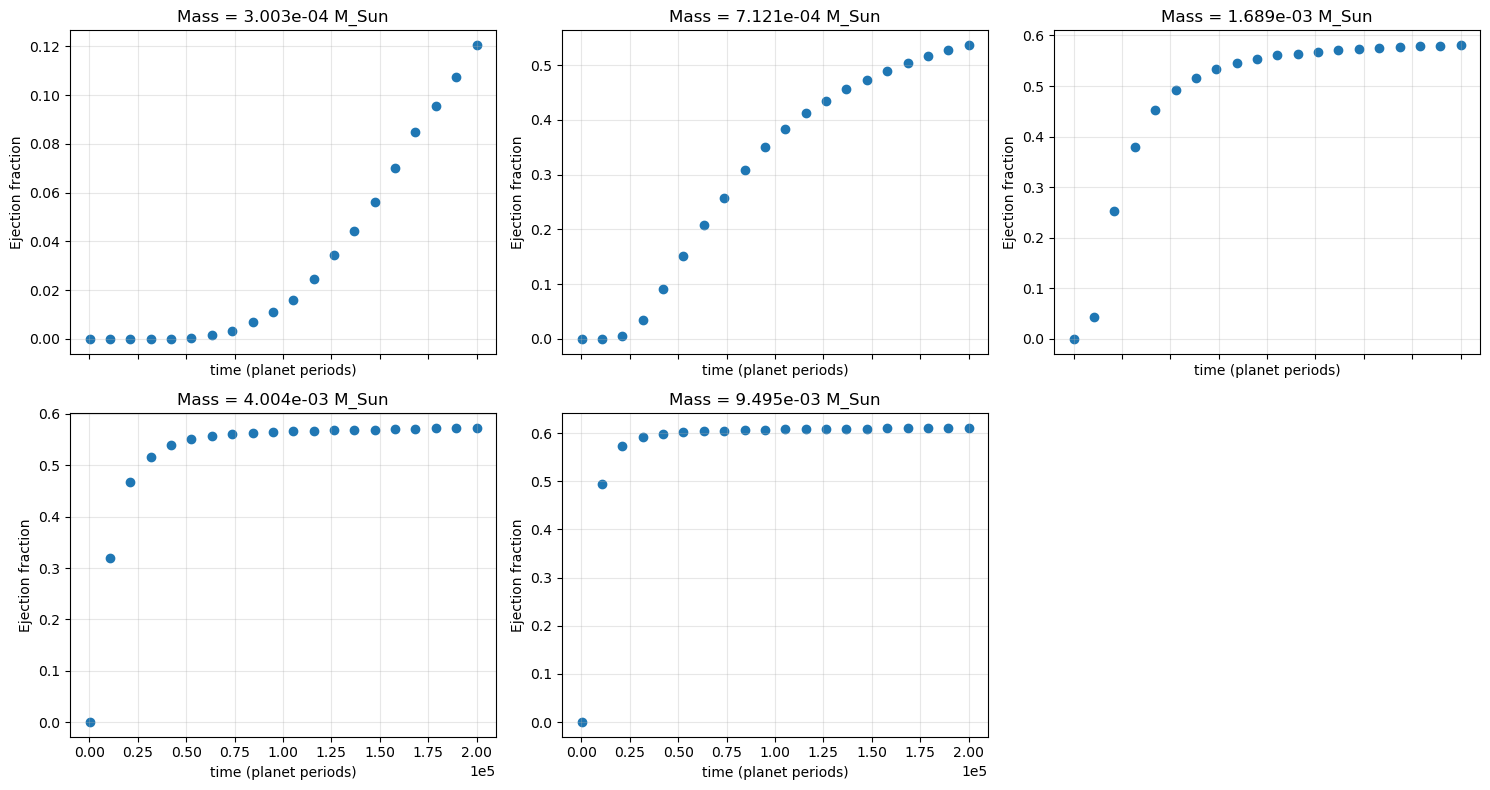

In [ ]:
masses = np.sort(grouped["mass"].unique())

ncols = 3
nrows = int(np.ceil(len(masses) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharex=True,
    sharey=False,
)

axes = np.atleast_1d(axes).ravel()

for ax, mass in zip(axes, masses):
    mass_df = (
        grouped[grouped["mass"] == mass]
        .sort_values("tmax")
    )

    ax.scatter(
        mass_df["tmax"],
        mass_df["ejection_fraction"],
    )

    ax.set_title(f"Mass = {mass:.3e} M_Sun")
    ax.set_xlabel("time (planet periods)")
    ax.set_ylabel("Ejection fraction")
    ax.grid(alpha=0.3)

    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    # Optional if tmax spans orders of magnitude
    # ax.set_xscale("log")

for ax in axes[len(masses):]:
    ax.remove()

fig.tight_layout()
#plt.savefig('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Visualizations/local_disc_convergence.png')

In [11]:
np.logspace(2, 3.5, 5)

array([ 100.        ,  237.13737057,  562.34132519, 1333.52143216,
       3162.27766017])

In [12]:
ejected_df=ejected_df.groupby(['mass','tmax']).size().reset_index(name='count')

In [13]:
ejected_df

,mass,tmax,count
0,0.000300,52705.263158,2
1,0.000300,63226.315789,9
2,0.000300,73747.368421,20
3,0.000300,84268.421053,41
4,0.000300,94789.473684,67
...,...,...,...
85,0.009495,157915.789474,3661
86,0.009495,168436.842105,3661
87,0.009495,178957.894737,3661
88,0.009495,189478.947368,3663


In [14]:
prop_df['prop_ejected']= ejected_df['count']/prop_df['count']

In [15]:
prop_df

,mass,tmax,count,prop_ejected
0,0.000300,100.000000,6000,0.000333
1,0.000300,10621.052632,6000,0.001500
2,0.000300,21142.105263,6000,0.003333
3,0.000300,31663.157895,6000,0.006833
4,0.000300,42184.210526,6000,0.011167
...,...,...,...,...
95,0.009495,157915.789474,6000,NaN
96,0.009495,168436.842105,6000,NaN
97,0.009495,178957.894737,6000,NaN
98,0.009495,189478.947368,6000,NaN


In [16]:
print(np.logspace(2, 5, 10))

[   100.            215.443469      464.15888336   1000.
   2154.43469003   4641.58883361  10000.          21544.34690032
  46415.88833613 100000.        ]
